# Training the model 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import xgboost as xgb

In [18]:
df = pd.read_csv("synthetic_soils.csv")

print(f"Loaded {len(df):,} rows")
print(df.head())

Loaded 15,000 rows
  source_soil     pH  N_total_mgkg  K_mgkg  habitability_score
0       Earth  7.624         3.755   6.231              0.5965
1       Earth  9.352         4.314   5.661              0.1567
2       Earth  8.696         6.982   3.466              0.3492
3       Earth  8.296         3.380   9.502              0.3625
4       Earth  6.968         7.088   7.673              0.7557


In [19]:
FEATURES = ["pH", "N_total_mgkg", "K_mgkg"]
TARGET = "habitability_score"
X = df[FEATURES]
y = df[TARGET]

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"training data: {len(X_train)}, testing data: {len(X_test)}")

training data: 12000, testing data: 3000


In [22]:
model = xgb.XGBRegressor(
    n_estimators=200,    
    max_depth=4,        
    learning_rate=0.05,  
    random_state=42,
    verbosity=0,
)

model.fit(X_train, y_train)
print("Model trained.")

Model trained.


In [24]:
# predict on the 20% held-back test rows
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

print(f"Mean Absolute Error : {mae:.4f} means that predictions are off by {mae:.4f} points on average (scale is 0-1)")
print(f"R² score            : {r2:.4f} means that model explains {r2*100:.1f}% of the variation in scores")

if r2 > 0.95:
    print("Very good fit")
elif r2 > 0.85:
    print("Decent fit")
else:
    print("Poor fit")

Mean Absolute Error : 0.0034 means that predictions are off by 0.0034 points on average (scale is 0-1)
R² score            : 0.9997 means that model explains 100.0% of the variation in scores
Very good fit


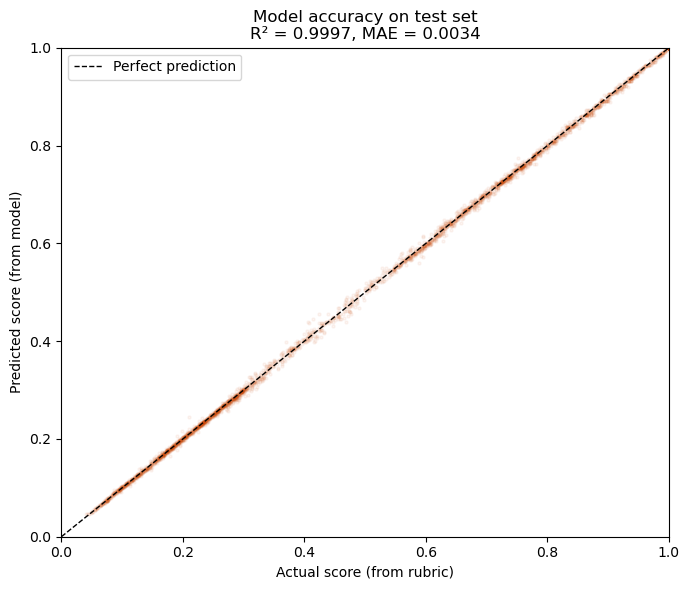

In [25]:
fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(y_test, y_pred, alpha=0.05, s=5, color="#CC4400")
ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Perfect prediction")

ax.set_xlabel("Actual score (from rubric)")
ax.set_ylabel("Predicted score (from model)")
ax.set_title(f"Model accuracy on test set\nR² = {r2:.4f}, MAE = {mae:.4f}")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend()

plt.tight_layout()
plt.savefig("model_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()

In [11]:
# These are the REAL measured values from Wamelink 2014
# The model has NEVER seen these — it only trained on synthetic data
real_soils = pd.DataFrame([
    {"soil": "Earth", "pH": 8.3, "N_total_mgkg": 0.5 + 4.2, "K_mgkg": 4.7},
    {"soil": "Moon",  "pH": 9.6, "N_total_mgkg": 0.3 + 4.2, "K_mgkg": 27.0},
    {"soil": "Mars",  "pH": 7.3, "N_total_mgkg": 3.9 + 2.1, "K_mgkg": 138.0},
])

# predict habitability for each real soil
predictions = model.predict(real_soils[FEATURES])
real_soils["model_prediction"] = predictions.round(3)

# the real experiment outcome (from the actual paper)
real_soils["real_biomass_mg"] = [61.57, 35.77, 131.42]
real_soils["real_ranking"]    = ["2nd", "3rd", "1st"]

print("=" * 55)
print("REAL VALIDATION — the moment of truth")
print("=" * 55)
print()
print(real_soils[["soil", "model_prediction", "real_biomass_mg", "real_ranking"]].to_string(index=False))
print()

# check if model ranking matches real ranking
ranked = real_soils.sort_values("model_prediction", ascending=False)["soil"].tolist()
print(f"Model ranking : {' > '.join(ranked)}")
print(f"Real ranking  : Mars > Earth > Moon")

mars  = real_soils[real_soils.soil=="Mars"]["model_prediction"].values[0]
earth = real_soils[real_soils.soil=="Earth"]["model_prediction"].values[0]
moon  = real_soils[real_soils.soil=="Moon"]["model_prediction"].values[0]
match = mars > earth > moon
print(f"Match: {'✓ YES' if match else '✗ NO — model needs work'}")

REAL VALIDATION — the moment of truth

 soil  model_prediction  real_biomass_mg real_ranking
Earth             0.396            61.57          2nd
 Moon             0.188            35.77          3rd
 Mars             0.848           131.42          1st

Model ranking : Mars > Earth > Moon
Real ranking  : Mars > Earth > Moon
Match: ✓ YES


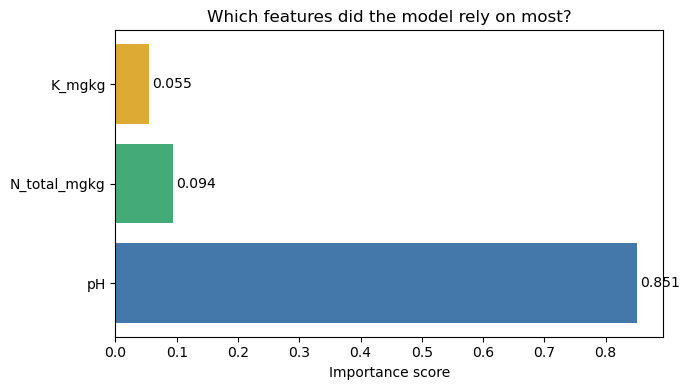

Higher = model leaned on this feature more when making predictions


In [12]:
# which feature did the model rely on most?
importances = model.feature_importances_
feat_names  = FEATURES

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.barh(feat_names, importances, color=["#4477AA", "#44AA77", "#DDAA33"])
ax.set_xlabel("Importance score")
ax.set_title("Which features did the model rely on most?")

for bar, val in zip(bars, importances):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f"{val:.3f}", va="center")

plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Higher = model leaned on this feature more when making predictions")

In [28]:
# save the trained model so you can load it later without retraining
with open("habitability_model.pkl", "wb") as f:
    pickle.dump(model, f)

In [27]:
# ── change these numbers to test any soil you want ───────────────────
my_soil = {
    "pH":          7.5,   # 0-14, most plants like 5.5-7.5
    "N_total_mgkg": 5.0,  # available nitrogen in mg per kg of soil
    "K_mgkg":      100.0, # potassium in mg per kg of soil
}
# ─────────────────────────────────────────────────────────────────────

input_df = pd.DataFrame([my_soil])
prediction = model.predict(input_df[FEATURES])[0]

print(f"Soil: {my_soil}\n")

print(f"Habitability score: {prediction:.3f} / 1.000\n")

if prediction > 0.7:
    print("Good")
elif prediction > 0.4:
    print("Okay")
else:
    print("Poor")

Soil: {'pH': 7.5, 'N_total_mgkg': 5.0, 'K_mgkg': 100.0}

Habitability score: 0.764 / 1.000

Good
